# Depth Migration
**Notebook Order: Imports • Definitions • Analysis | Sweeps Data Provided**

## Imports

In [1]:
import random, collections
import numpy as np
import chess
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.precision", 3)

from chessformer_lens import interp_plot as ip
from chessformer_lens.engine import MaiaEngine   # the interp core

import figstyle
figstyle.apply()                   # switches interp_plot's figures to match

FIGDIR = Path("depth_migration_data")          # the sweeps
OUT = Path("figures_without_sweeps")           

def show(fig, name=None):
    if name is not None:
        OUT.mkdir(exist_ok=True)
        fig.savefig(OUT / f"{name}.png", dpi=300, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    display(fig)
    plt.close(fig)


In [2]:
PIECES = ["pawn", "bishop", "knight", "rook"]
ELOS = list(range(700, 2501, 100))

eng = MaiaEngine("maia3-23m", device="mps")   # only for the example position and the atlases; switch to cuda for gpu

load = lambda arm: np.load(FIGDIR / f"elo_ladder_23m{arm}.npz", allow_pickle=True)
L, F, S, Q, B, PZ, CM = [load(a) for a in ["", "_2x2", "_salience", "_quiet", "_blunder", "_puzzle_concepts", "_commit"]]
# forks, the 2x2 surgeries, best alternative, quiet, blunder, puzzle concepts, commit depth


## Definitions

In [11]:
CELLS = ["fork", "check_only", "double_attack", "single"]
SPARE = (chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN)
spare_rng = random.Random(0)      # seed I used
spare_seen = collections.Counter()  




# these comes from the mining.py module
VALUE = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9}
_SEE_VALUE = {**VALUE, chess.KING: 100}

def exchange_loss(board, move):
    b = board.copy()
    b.push(move)
    sq = move.to_square

    def gain(b, side, on):
        for s in sorted(b.attackers(side, sq), key=lambda s: _SEE_VALUE[b.piece_at(s).piece_type]):
            a = b.piece_at(s).piece_type
            if a == chess.KING and b.attackers(not side, sq):
                continue
            c = b.copy()
            c.remove_piece_at(s)
            c.set_piece_at(sq, chess.Piece(a, side))
            return max(0, on - gain(c, not side, _SEE_VALUE[a]))
        return 0

    return gain(b, b.turn, _SEE_VALUE[board.piece_at(move.from_square).piece_type])



def trim(board, move, keep, rounds=8):
    # careful board edits to make the surgeries
    b = board.copy()
    for _ in range(rounds):
        b.push(move)
        extra = [s for s in b.attacks(move.to_square) & b.occupied_co[b.turn]
                 if s not in keep and b.piece_at(s).piece_type != chess.KING]
        b.pop()
        if not extra:
            return b if b.is_valid() and move in b.legal_moves else None
        for s in extra:
            b.remove_piece_at(s)
        if not b.is_valid() or move not in b.legal_moves:
            return None
    return None


def relocate_king(board, move):
    """Board with the enemy king on the nearest square where the move still hits its target but
    gives no check, so the position is perturbed as little as possible. It also must not change
    whether the mover is attacked. None if there is none."""
    b0 = board.copy()
    b0.push(move)
    foe = b0.turn
    hung = b0.is_attacked_by(foe, move.to_square)
    targets = {s for s in b0.attacks(move.to_square) & b0.occupied_co[foe]
               if b0.piece_at(s).piece_type != chess.KING}

    stripped = board.copy()
    home = stripped.king(foe)
    stripped.remove_piece_at(home)
    for sq in sorted(chess.SQUARES, key=lambda s: chess.square_distance(s, home)):
        if stripped.piece_at(sq) is not None or sq == move.to_square:
            continue
        b = stripped.copy()
        b.set_piece_at(sq, chess.Piece(chess.KING, foe))
        if not b.is_valid() or move not in b.legal_moves:
            continue
        b.push(move)
        ok = (not b.is_check()
              and b.is_attacked_by(b.turn, move.to_square) == hung
              and targets <= set(b.attacks(move.to_square)))
        b.pop()
        if ok:
            return b
    return None


def substitute(board, move, relocated, home, keep):
    b0 = relocated.copy()
    b0.push(move)
    foe = b0.turn
    spoken_for = set(b0.attacks(move.to_square) & b0.occupied_co[foe])
    hung = b0.is_attacked_by(foe, move.to_square)

    cells = {}
    for sq, pc in relocated.piece_map().items():
        if pc.color != foe or pc.piece_type not in SPARE or sq in spoken_for:
            continue
        b = relocated.copy()
        b.remove_piece_at(sq)
        b.set_piece_at(home, pc)
        if not b.is_valid() or move not in b.legal_moves:
            continue
        b = trim(b, move, keep | {home})
        if b is None or exchange_loss(b, move):
            continue
        b.push(move)
        ok = home in b.attacks(move.to_square) and b.is_attacked_by(b.turn, move.to_square) == hung
        b.pop()
        if ok:
            cells.setdefault(pc.piece_type, []).append(b)
    if not cells:
        return None
    forker = board.piece_at(move.from_square).piece_type
    pt = min(cells, key=lambda t: (spare_seen[forker, t], spare_rng.random()))
    spare_seen[forker, pt] += 1
    return spare_rng.choice(cells[pt])


def shape(board, move):
    b = board.copy()
    b.push(move)
    return b.is_check(), len(b.attacks(move.to_square) & b.occupied_co[b.turn])


def variants(board, move):
    b = board.copy()
    b.push(move)
    foe = b.turn
    others = [s for s in b.attacks(move.to_square) & b.occupied_co[foe]
              if b.piece_at(s).piece_type != chess.KING]
    checks, home = b.is_check(), board.king(foe)
    if not checks or not others:
        return None
    primary = max(others, key=lambda s: VALUE[b.piece_at(s).piece_type])

    fork = trim(board, move, {primary})               # king + primary, nothing incidental
    if fork is None:
        return None
    relocated = relocate_king(fork, move)
    if relocated is None:
        return None
    v = {"fork": fork,
         "check_only": trim(fork, move, set()),
         "single": trim(relocated, move, {primary}),
         "double_attack": substitute(fork, move, relocated, home, {primary})}
    want = {"fork": (True, 2), "check_only": (True, 1),
            "double_attack": (False, 2), "single": (False, 1)}
    return v if all(v[c] is not None and shape(v[c], move) == want[c]
                    and not exchange_loss(v[c], move) for c in CELLS) else None



# Results

Figures are initially purely created with chessformer_lens, but here more hand-crafted to fit the specific paper style and how it uses LaTeX

## 1) How does the depth of causal center of mass for forks migrate over ELOs?

In [5]:
def com_curve(D):
    """Layer centre of mass at every Elo, pooled over positions: (positions, Elos, layers, heads) -> (Elos,)."""
    m = np.abs(D).sum(-1).mean(0)
    return (m * np.arange(m.shape[-1])).sum(-1) / m.sum(-1)


def com_rows(D):
    """The same kept per position: (positions, Elos). NaN where a position carries no mass."""
    m = np.abs(D).sum(-1)
    with np.errstate(invalid="ignore", divide="ignore"):
        return (m * np.arange(m.shape[-1])).sum(-1) / m.sum(-1)


def shift(D):
    """Layers moved from the first Elo to the last, one value per position."""
    c = com_rows(D)
    return c[:, -1] - c[:, 0]


def ci(x):
    """Mean and 95% confidence intervals."""
    x = x[np.isfinite(x)]
    return x.mean(), 1.96 * x.std(ddof=1) / np.sqrt(len(x))


def pm(x):
    return "%+.3f ± %.3f" % ci(x)


top = {p: L[f"top1__{p}"].all(1) for p in PIECES}     # positions where the fork is the model's move at every Elo

com = pd.DataFrame({p: com_curve(L[f"D__{p}"][top[p]]) for p in PIECES}, index=ELOS).T
com.assign(shift=com[2500] - com[700], n=[top[p].sum() for p in PIECES])


,700,800,900,1000,1100,1200,1300,1400,1500,1600,...,1800,1900,2000,2100,2200,2300,2400,2500,shift,n
pawn,3.111,3.263,3.372,3.441,3.482,3.507,3.525,3.538,3.549,3.559,...,3.577,3.586,3.596,3.607,3.618,3.627,3.632,3.634,0.523,261
bishop,3.305,3.413,3.480,3.525,3.560,3.589,3.612,3.631,3.647,3.661,...,3.691,3.708,3.727,3.748,3.771,3.793,3.812,3.827,0.522,243
knight,3.318,3.492,3.641,3.751,3.829,3.887,3.931,3.966,3.996,4.023,...,4.071,4.093,4.113,4.134,4.155,4.174,4.190,4.202,0.884,368
rook,3.131,3.238,3.316,3.368,3.407,3.439,3.468,3.491,3.511,3.527,...,3.553,3.565,3.578,3.590,3.602,3.613,3.621,3.626,0.494,238


In [7]:
# Per-step sizes with 95% CIs, and a permutation test: shuffle the Elo labels within each position
# and recompute the pooled centre-of-mass curve.
rng = np.random.default_rng(0)


def permutation(D, B=1000):
    """The total shift and the number of rising steps, with p-values against shuffled Elo labels."""
    obs = com_curve(D)
    null = []
    for _ in range(B):
        order = np.argsort(rng.random(D.shape[:2]), axis=1)
        null.append(com_curve(np.take_along_axis(D, order[:, :, None, None], axis=1)))
    null = np.array(null)
    return dict(shift=obs[-1] - obs[0], rising=(np.diff(obs) > 0).sum(),
                p_shift=(np.abs(null[:, -1] - null[:, 0]) >= abs(obs[-1] - obs[0])).mean(),
                p_rising=((np.diff(null) > 0).sum(1) >= (np.diff(obs) > 0).sum()).mean())


steps = {p: np.diff(com_rows(L[f"D__{p}"][top[p]]), axis=1) for p in PIECES}         # (positions, 18)
display(pd.DataFrame({p: [pm(s) for s in steps[p].T] for p in PIECES},
                     index=[f"{a}→{b}" for a, b in zip(ELOS, ELOS[1:])]))
pd.DataFrame({p: permutation(L[f"D__{p}"][top[p]]) for p in PIECES}).T.astype({"rising": int})


,pawn,bishop,knight,rook
700→800,+0.146 ± 0.010,+0.108 ± 0.010,+0.169 ± 0.007,+0.111 ± 0.009
800→900,+0.107 ± 0.009,+0.069 ± 0.009,+0.145 ± 0.006,+0.082 ± 0.008
900→1000,+0.067 ± 0.007,+0.046 ± 0.008,+0.107 ± 0.005,+0.056 ± 0.007
1000→1100,+0.040 ± 0.005,+0.035 ± 0.006,+0.077 ± 0.004,+0.041 ± 0.006
1100→1200,+0.024 ± 0.004,+0.029 ± 0.005,+0.057 ± 0.003,+0.034 ± 0.005
1200→1300,+0.017 ± 0.003,+0.023 ± 0.004,+0.044 ± 0.003,+0.030 ± 0.004
1300→1400,+0.012 ± 0.003,+0.019 ± 0.003,+0.035 ± 0.002,+0.024 ± 0.003
1400→1500,+0.010 ± 0.003,+0.016 ± 0.003,+0.030 ± 0.002,+0.019 ± 0.003
1500→1600,+0.010 ± 0.003,+0.015 ± 0.003,+0.027 ± 0.002,+0.016 ± 0.003
1600→1700,+0.010 ± 0.004,+0.015 ± 0.003,+0.025 ± 0.002,+0.013 ± 0.003


,shift,rising,p_shift,p_rising
pawn,0.523,18,0.0,0.0
bishop,0.522,18,0.0,0.0
knight,0.884,18,0.0,0.0
rook,0.494,18,0.0,0.0


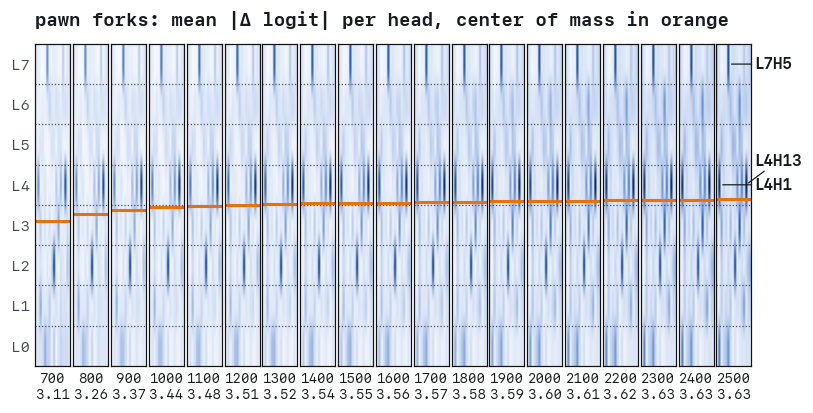

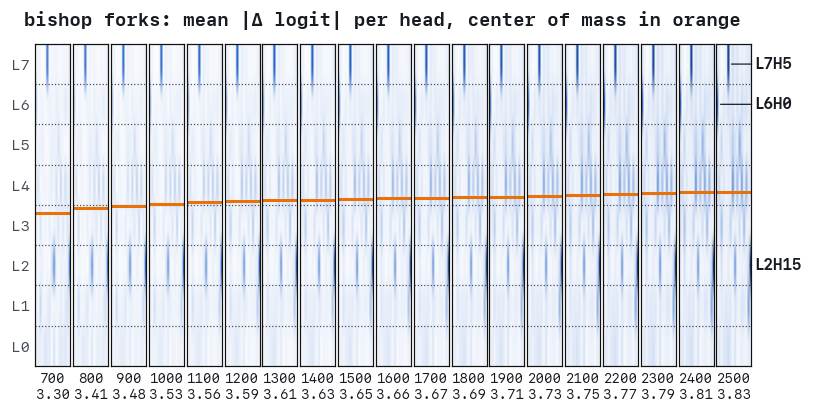

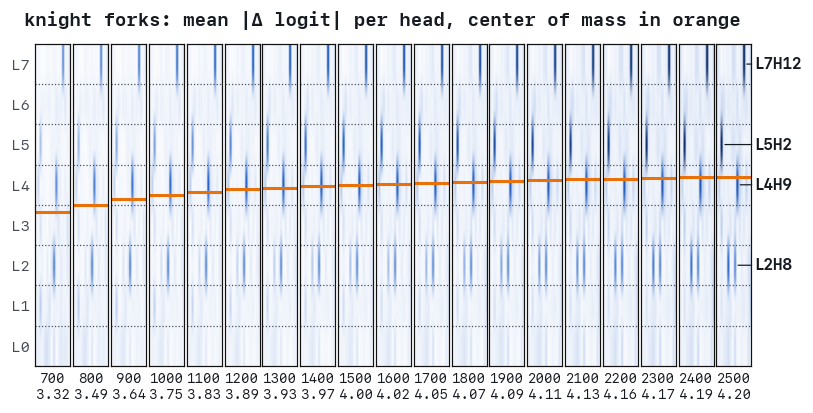

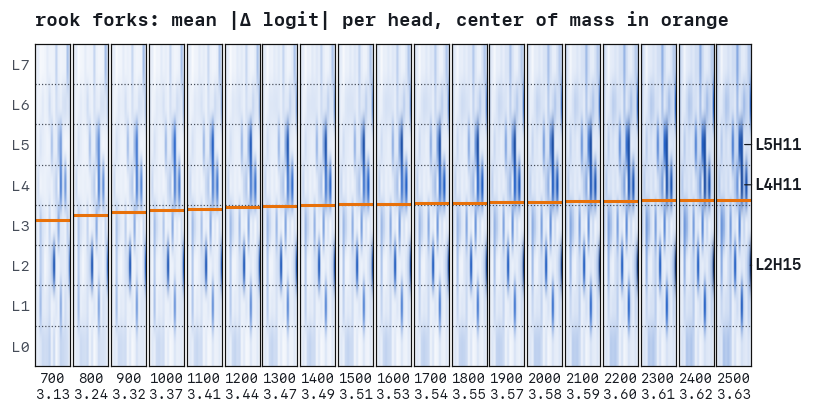

In [37]:
# Ladder plots. The star of the paper. Power scale (gamma .8) so heads below the strongest one do not print white.
from matplotlib.colors import PowerNorm
COM_COL = "#e8710a"                  
GAMMA = 0.8

for p in PIECES:
    D = np.abs(L[f"D__{p}"][top[p]])
    grids, coms = D.mean(0), com_curve(D)
    vmax, nL, nH = grids.max(), D.shape[2], D.shape[3]

    fig, axes = plt.subplots(1, len(ELOS), figsize=(8.4, 3.8), sharey=True,
                                gridspec_kw=dict(wspace=.08))
    for j, ax in enumerate(axes):
        ax.imshow(grids[j], cmap=figstyle.SEQMAP, norm=PowerNorm(GAMMA, vmin=0, vmax=vmax),
                    aspect="auto", origin="lower")   # deeper layers up
        for y in range(1, nL):                                     # layer boundaries
            ax.axhline(y - .5, color=figstyle.MUTED, lw=.8, ls=":")
        ax.axhline(coms[j], color=COM_COL, lw=2)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor("#111"); sp.set_linewidth(.8)
        ax.set_xlabel(f"{ELOS[j]}\n{coms[j]:.2f}", fontsize=9, color=figstyle.TEXT)
        ax.set_xticks([])
        ax.tick_params(length=0)
        ax.grid(False)
    axes[0].set_yticks(range(nL), [f"L{i}" for i in range(nL)], fontsize=10)
    # label the three heaviest heads at 2500, plus L2H8 on the knight
    named = {divmod(int(k), nH) for k in np.argsort(-grids[-1].ravel())[:3]}
    named = sorted(named | ({(2, 8)} if p == "knight" else set()))
    ys = [float(lay) for lay, _ in named]
    for a in range(1, len(ys)):                                
        ys[a] = max(ys[a], ys[a - 1] + 0.6)
    for (lay, h), y in zip(named, ys):
        axes[-1].annotate(f"L{lay}H{h}", xy=(h, lay), xytext=(nH + 1.0, y),
                            fontsize=10, color=figstyle.TEXT, fontweight="bold",
                            ha="left", va="center", annotation_clip=False,
                            arrowprops=dict(arrowstyle="-", color=figstyle.TEXT, lw=.8, shrinkA=0, shrinkB=2))
    fig.suptitle(f"{p} forks: mean |Δ logit| per head, center of mass in orange",
                    color=figstyle.TEXT, fontsize=12, fontweight="bold", y=.96)
    show(fig, f"ladder_{p}")


## 2) Does everything migrate? The Global result.

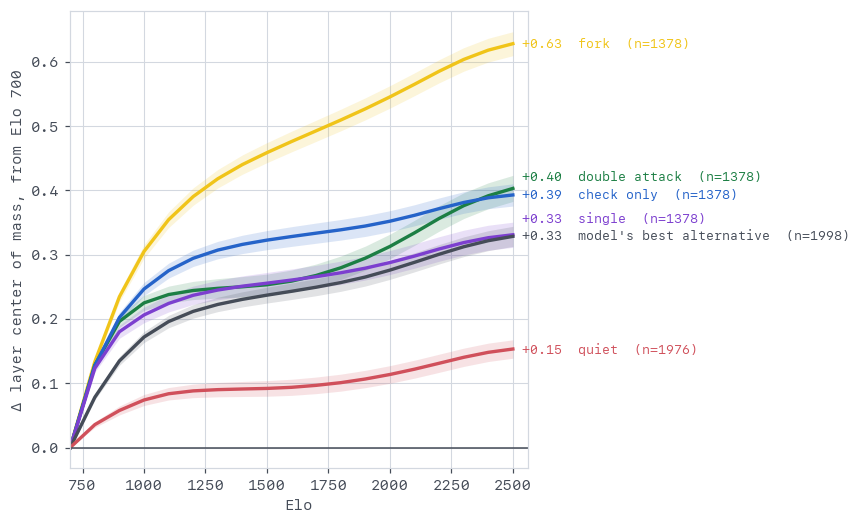

In [7]:
# Every arm, pooled over pieces, each referenced to its own depth at the first run: Elo=700. Always using 1.96 SE.
ARMS = [("fork",    F, "D__{}__fork",          figstyle.HL),
        ("double attack", F, "D__{}__double_attack", figstyle.ACCENT2),
        ("check only",      F, "D__{}__check_only",    figstyle.ACCENT),
        ("single", F, "D__{}__single",        figstyle.MLCOLORS[3]),
        ("model's best alternative",     S, "D__{}__alt",           figstyle.MUTED),
        ("quiet", Q, "D__{}__quiet", figstyle.LOSS)]

fig, ax = plt.subplots(figsize=(8.4, 5.4))
ends = []
for label, Z, tmpl, col in ARMS:
    C = np.vstack([com_rows(Z[tmpl.format(p)]) for p in PIECES])
    C = C[np.isfinite(C).all(1)]
    d = C - C[:, [0]]
    m, se = d.mean(0), 1.96 * d.std(0, ddof=1) / np.sqrt(len(d))
    ax.plot(ELOS, m, "-", lw=2.2, color=col)
    ax.fill_between(ELOS, m - se, m + se, color=col, alpha=.16, lw=0)
    ends.append([m[-1], f"{m[-1]:+.2f}  {label}  (n={len(C)})", col])

ax.axhline(0, color=figstyle.MUTED, lw=1)
ax.set_xlabel("Elo", color=figstyle.MUTED)
ax.set_ylabel("Δ layer center of mass, from Elo 700", color=figstyle.MUTED)
gap = .045 * (max(e[0] for e in ends) - 0)        
ends.sort(key=lambda e: e[0])
for lo, hi in zip(ends, ends[1:]):
    hi[0] = max(hi[0], lo[0] + gap)
for y, txt, col in ends:
    ax.annotate(txt, (ELOS[-1], y), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=col, annotation_clip=False)
ax.set_xlim(ELOS[0], ELOS[-1] + 60)
fig.subplots_adjust(right=.62)
show(fig, "all_arms")

## 3) Is there structure in the migration/recruitment

In [8]:
# The 2x2 surgeries: centre-of-mass shift per cell, on the positions where all four cells are finite.
ok = {p: np.all([np.isfinite(shift(F[f"D__{p}__{c}"])) for c in CELLS], 0) for p in PIECES}
pd.DataFrame({c: [pm(shift(F[f"D__{p}__{c}"])[ok[p]]) for p in PIECES] for c in CELLS},
             index=PIECES).assign(n=[ok[p].sum() for p in PIECES])


,fork,check_only,double_attack,single,n
pawn,+0.548 ± 0.037,+0.537 ± 0.033,+0.482 ± 0.042,+0.510 ± 0.041,355
bishop,+0.533 ± 0.034,+0.284 ± 0.032,+0.256 ± 0.035,+0.183 ± 0.034,385
knight,+0.864 ± 0.026,+0.400 ± 0.033,+0.558 ± 0.037,+0.342 ± 0.036,392
rook,+0.516 ± 0.040,+0.343 ± 0.033,+0.273 ± 0.037,+0.286 ± 0.036,246


In [8]:
# Concept ranking: solution-minus-alternative shift per concept, bootstrap CI. Goes up to 2300 because this sweep was less fine grained.
def excess(sol, alt):
    """Mean paired difference with a bootstrap 95% interval."""
    d = sol - alt
    d = d[np.isfinite(d)]
    boot = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(1000)]
    return dict(n=len(d), excess=d.mean(), low=np.percentile(boot, 2.5), high=np.percentile(boot, 97.5))


concepts = [k[3:-5] for k in PZ.files if k.startswith("D__") and k.endswith("__sol")]
rows = {t: excess(shift(PZ[f"D__{t}__sol"]), shift(PZ[f"D__{t}__alt"])) for t in concepts}

k = ELOS.index(int(PZ["elos"][-1]))                    # the royal knight fork over the same Elo range
fork, alt = (com_rows(S[f"D__knight__{a}"]) for a in ("fork", "alt"))
rows["royal knight fork"] = excess(fork[:, k] - fork[:, 0], alt[:, k] - alt[:, 0])
pd.DataFrame(rows).T.astype({"n": int}).sort_values("excess", ascending=False)


,n,excess,low,high
royal knight fork,500,0.513,0.479,0.545
smotheredMate,350,0.300,0.256,0.344
discoveredAttack,350,0.279,0.223,0.336
hangingPiece,350,0.235,0.185,0.287
fork,350,0.202,0.154,0.248
discoveredCheck,350,0.178,0.131,0.226
endgame,350,0.174,0.119,0.227
mateIn1,350,0.154,0.112,0.199
zugzwang,350,0.128,0.079,0.178
mateIn3,350,0.115,0.070,0.170


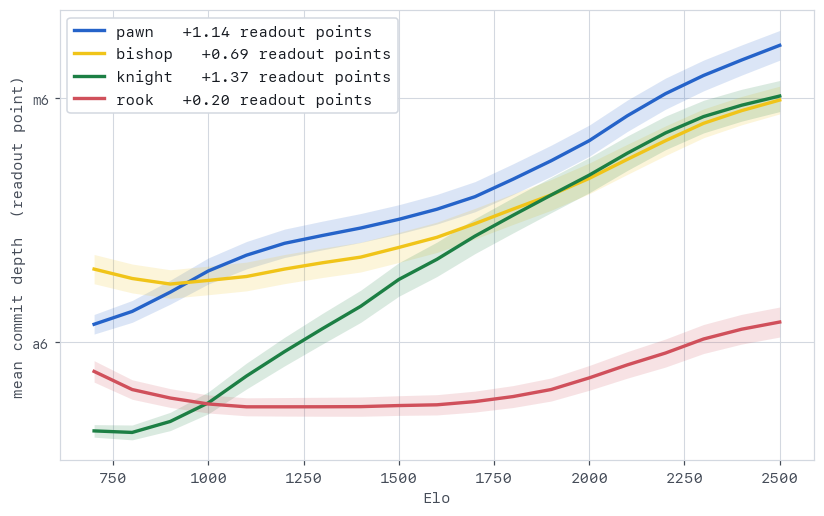

In [10]:
# Commit depth plot. The y axis is readout points (18 of them), not layers, so the heights are
# not comparable to the center of mass; the shape is.
PIECE_COL = {"pawn": figstyle.ACCENT, "bishop": figstyle.HL,
             "knight": figstyle.ACCENT2, "rook": figstyle.LOSS}

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for p in PIECES:
    d = CM[f"commit__{p}"]                              # (positions, rungs)
    m = np.nanmean(d, 0)
    se = 1.96 * np.nanstd(d, 0, ddof=1) / np.sqrt(np.isfinite(d).sum(0))
    ax.plot(ELOS, m, "-", lw=2.2, color=PIECE_COL[p],
            label=f"{p}   {m[-1] - m[0]:+.2f} readout points")
    ax.fill_between(ELOS, m - se, m + se, color=PIECE_COL[p], alpha=.16, lw=0)

ax.set_xlabel("Elo", color=figstyle.MUTED)
names = [lab for _, lab, _ in eng._lens_steps()]
lo, hi = ax.get_ylim()
ax.set_yticks(range(len(names)), names, fontsize=9)
ax.set_ylim(lo, hi)
ax.set_ylabel("mean commit depth  (readout point)", color=figstyle.MUTED)
figstyle.legend(ax, loc="upper left", fontsize=10)
fig.tight_layout()
show(fig, "commit_depth_plot")


# 4) Controls


## confidence: moves the model likes less still migrate


In [39]:
# Confidence control: if depth tracked confidence, moves whose probability falls with Elo would migrate
# shallower. Best alternative, blunders, and forks whose own probability falls, plus the per-position
# correlation between a fork's migration and its confidence gain.
def arm(D, P, ok=True):
    """One row per move type: positions, the move's probability at 700 and 2500 and the share of positions
    where it falls, the shift with its CI, and how many of the 18 Elo steps the pooled centre of mass rises."""
    ok = ok & np.isfinite(shift(D))
    return dict(n=ok.sum(), p700=P[ok, 0].mean(), p2500=P[ok, -1].mean(), p_falls=(P[ok, -1] < P[ok, 0]).mean(),
                shift=pm(shift(D)[ok]), rising=(np.diff(com_curve(D[ok])) > 0).sum())


def confidence_r(p):
    s, lp = shift(L[f"D__{p}"]), np.log10(np.clip(L[f"p__{p}"], 1e-9, None))
    ok = np.isfinite(s)
    return np.corrcoef(s[ok], lp[ok, -1] - lp[ok, 0])[0, 1]


pd.Series({p: confidence_r(p) for p in PIECES})
falls = {p: L[f"p__{p}"][:, -1] < L[f"p__{p}"][:, 0] for p in PIECES}
pd.DataFrame({("best alternative", p): arm(S[f"D__{p}__alt"], S[f"p__{p}__alt"], S[f"top1__{p}__fork"].all(1)) for p in PIECES}
             | {("blunder", p): arm(B[f"D__{p}__blunder"], B[f"p__{p}__blunder"]) for p in PIECES}
             | {("fork whose p falls", p): arm(L[f"D__{p}"], L[f"p__{p}"], falls[p]) for p in PIECES}).T


n   p700  p2500 p_falls           shift rising
best alternative   pawn    259  0.147  0.068   0.776  +0.220 ± 0.039     14
                   bishop  243  0.128  0.061   0.794  +0.229 ± 0.039     18
                   knight  368  0.144  0.057   0.848  +0.290 ± 0.035     18
                   rook    238  0.134  0.094   0.727  +0.260 ± 0.045     18
blunder            pawn    474  0.052  0.017    0.93  +0.209 ± 0.031     17
                   bishop  499  0.071  0.047   0.884  +0.249 ± 0.030     18
                   knight  500  0.053  0.017    0.91  +0.318 ± 0.030     18
                   rook    500   0.06   0.03     0.9  +0.218 ± 0.029     17
fork whose p falls pawn     60  0.325  0.179     1.0  +0.293 ± 0.092     11
                   bishop   44  0.175  0.065     1.0  +0.162 ± 0.107      9
                   knight    3  0.301  0.225     1.0  +0.578 ± 0.225     11
                   rook     99  0.246  0.106     1.0  +0.273 ± 0.056     18

## blunder: a move that hangs a piece

In [40]:
# Blunder arm pooled over pieces.
pooled = np.concatenate([shift(B[f"D__{p}__blunder"]) for p in PIECES])
pm(pooled), int(np.isfinite(pooled).sum())


('+0.249 ± 0.015', 1973)

# 5) Mechanism first pass

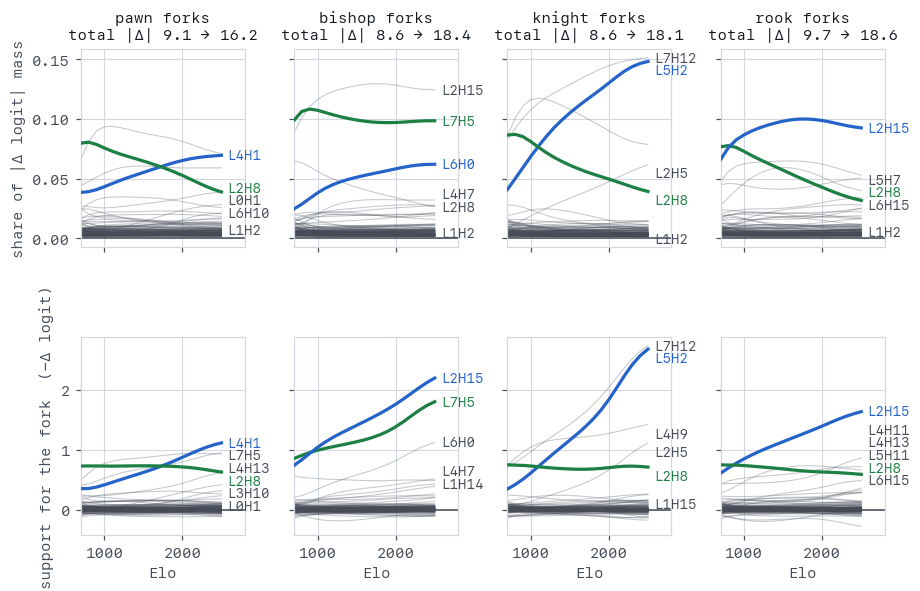

In [13]:
# Per-head trajectories: share of total |Δ| (what the center of mass is built from) and
# absolute −Δ (up = supports the fork).


def series(p, mode):
    """(rungs, layers*heads) per-head curve for one piece: share of |Δ| mass, or −Δ."""
    D = L[f"D__{p}"][F[f"keep__{p}"]]
    total = np.abs(D).mean(0).sum((1, 2))
    y = np.abs(D).mean(0) / total[:, None, None] if mode == "share" else -D.mean(0)
    return y.reshape(len(ELOS), -1), total, D.shape[3]


fig, grid = plt.subplots(2, len(PIECES), figsize=(8.4, 5.6), sharex=True, sharey="row",
                         squeeze=False)
for row, mode in enumerate(("share", "absolute")):
    axes = grid[row:row + 1]
    SPAN = max(series(p, mode)[0].max() for p in PIECES) - min(series(p, mode)[0].min() for p in PIECES)
    for ax, p in zip(axes[0], PIECES):
        y, total, nH = series(p, mode)
        mover = int((y[-1] - y[0]).argmax())                      # biggest increase in this view
        novice = int(np.abs(y[0]).argmax())                       # the head carrying it at 700

        ax.axhline(0, color=figstyle.MUTED, lw=1)
        ax.plot(ELOS, y, color=figstyle.MUTED, lw=.7, alpha=.3)
        labels = []
        named = {int(k) for k in np.argsort(-np.abs(y[-1] - y[0]))[:5]} | {mover, novice}
        for k in named:                                          # two drawn, the rest only labelled
            lay, h = divmod(k, nH)
            col = figstyle.ACCENT2 if k == novice else figstyle.ACCENT if k == mover else figstyle.MUTED
            if k in (mover, novice):
                ax.plot(ELOS, y[:, k], color=col, lw=2.1, zorder=3)
            labels.append([y[-1, k], f"L{lay}H{h}", col])
        gap = .07 * SPAN                          # spread the right-edge labels apart
        labels.sort(key=lambda t: t[0])
        for lo, hi in zip(labels, labels[1:]):
            hi[0] = max(hi[0], lo[0] + gap)
        over = labels[-1][0] - y.max()
        if over > 0:
            for t in labels:
                t[0] -= over
            for hi, lo in zip(labels[::-1], labels[::-1][1:]):
                lo[0] = min(lo[0], hi[0] - gap)
        for ly, txt, col in labels:
            ax.annotate(txt, (ELOS[-1], ly), xytext=(4, 0), textcoords="offset points",
                        va="center", fontsize=9, color=col, annotation_clip=False)
        ax.set_xlim(ELOS[0], ELOS[-1] + 300)
        ax.set_title(f"{p} forks\ntotal |Δ| {total[0]:.1f} → {total[-1]:.1f}" if row == 0
                     else "", fontsize=10, color=figstyle.TEXT)
        if row == 1:
            ax.set_xlabel("Elo", color=figstyle.MUTED)
    axes[0][0].set_ylabel("share of |Δ logit| mass" if mode == "share"
                          else "support for the fork  (−Δ logit)", color=figstyle.MUTED)
fig.subplots_adjust(left=.08, right=.95, top=.88, bottom=.09, hspace=.45, wspace=.3)
show(fig, "head_trajectories")


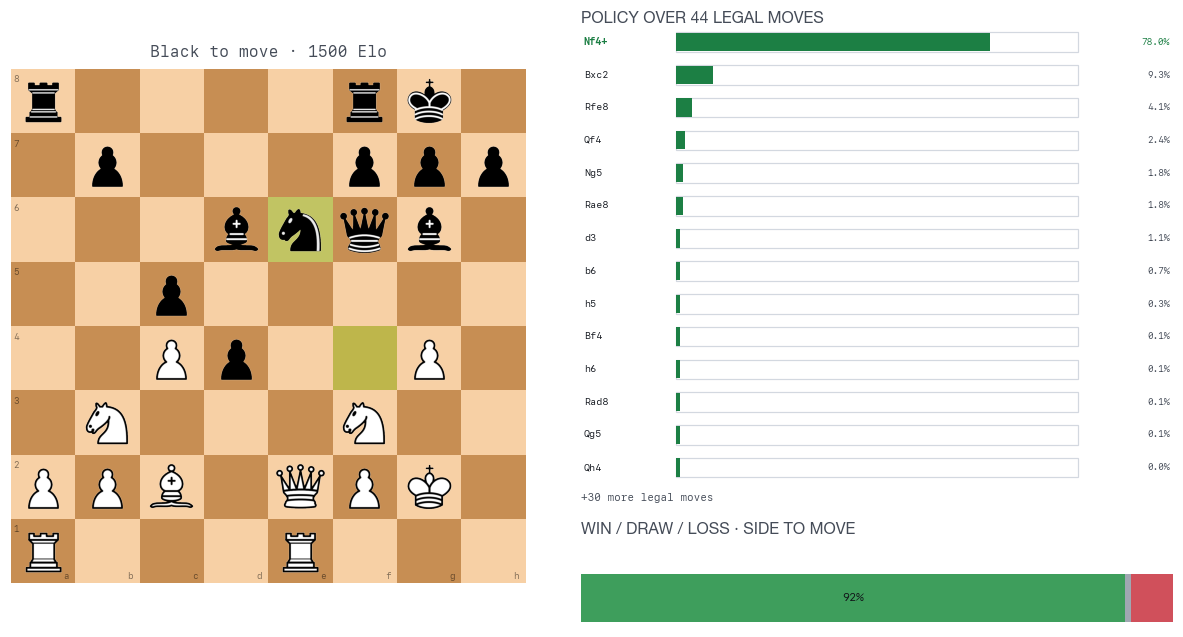

In [9]:
random_board=chess.Board("r4rk1/1p3ppp/3bnqb1/2p5/2Pp2P1/1N3N2/PPB1QPK1/R3R3 b - - 1 1") 
#random yes but picked so that there are knight fork themes

show((ip.plot_position(eng,random_board)),"sparse_board")

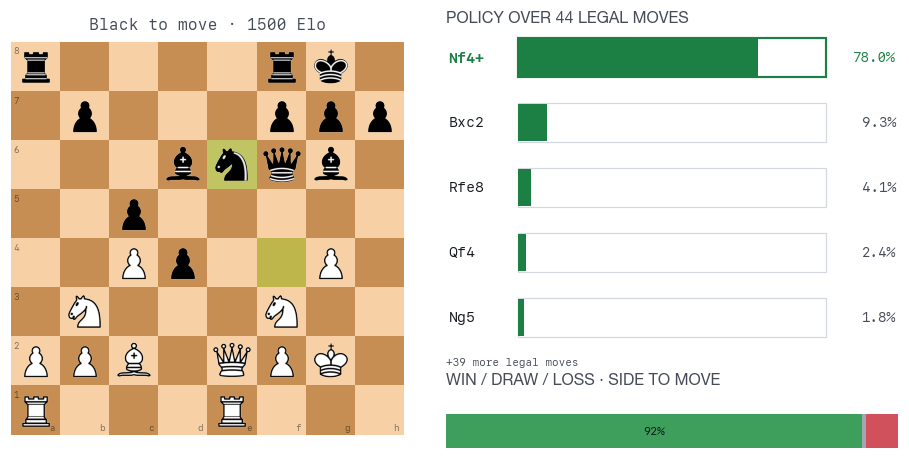

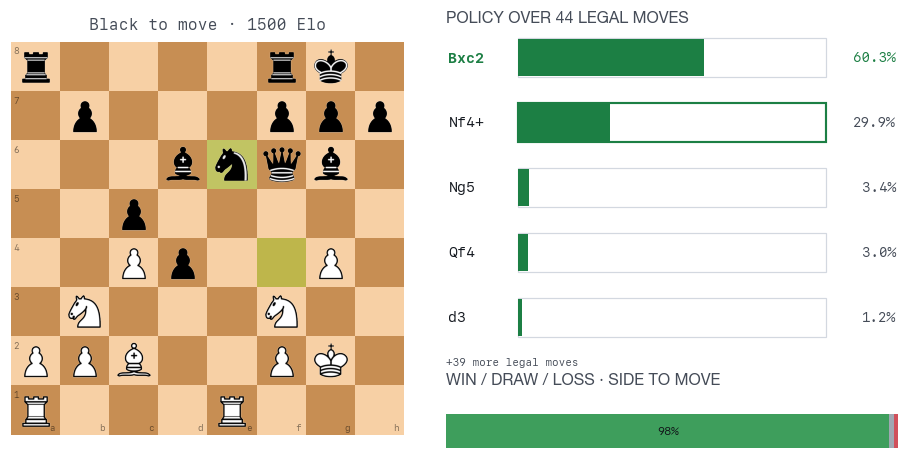

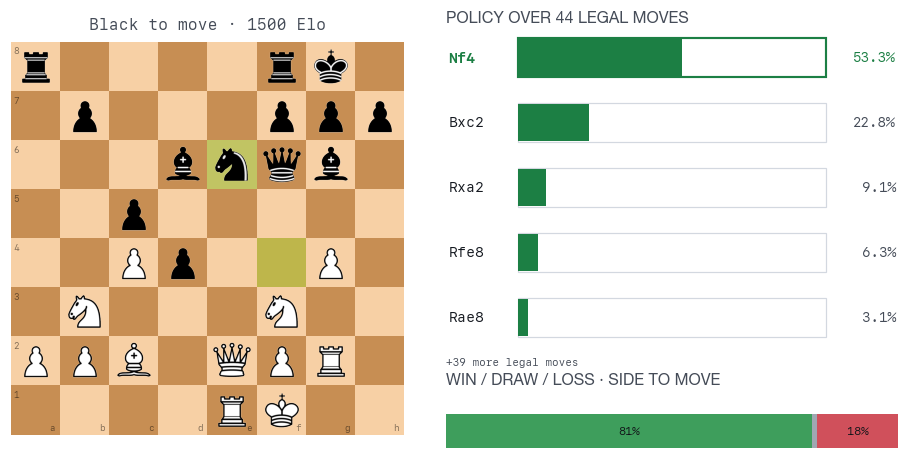

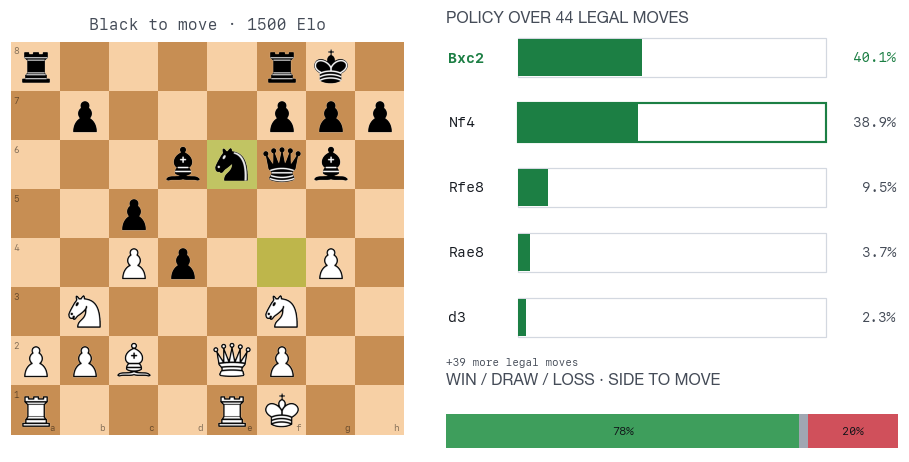

In [12]:
# the running example and surgeries.
ex = variants(random_board, chess.Move.from_uci("e6f4"))
for c in CELLS:
    show(ip.plot_position(eng, ex[c], 1500, played="e6f4", max_moves=5, figsize=(8.4, 4.4)),
         f"ex_knight_fork_{c}")


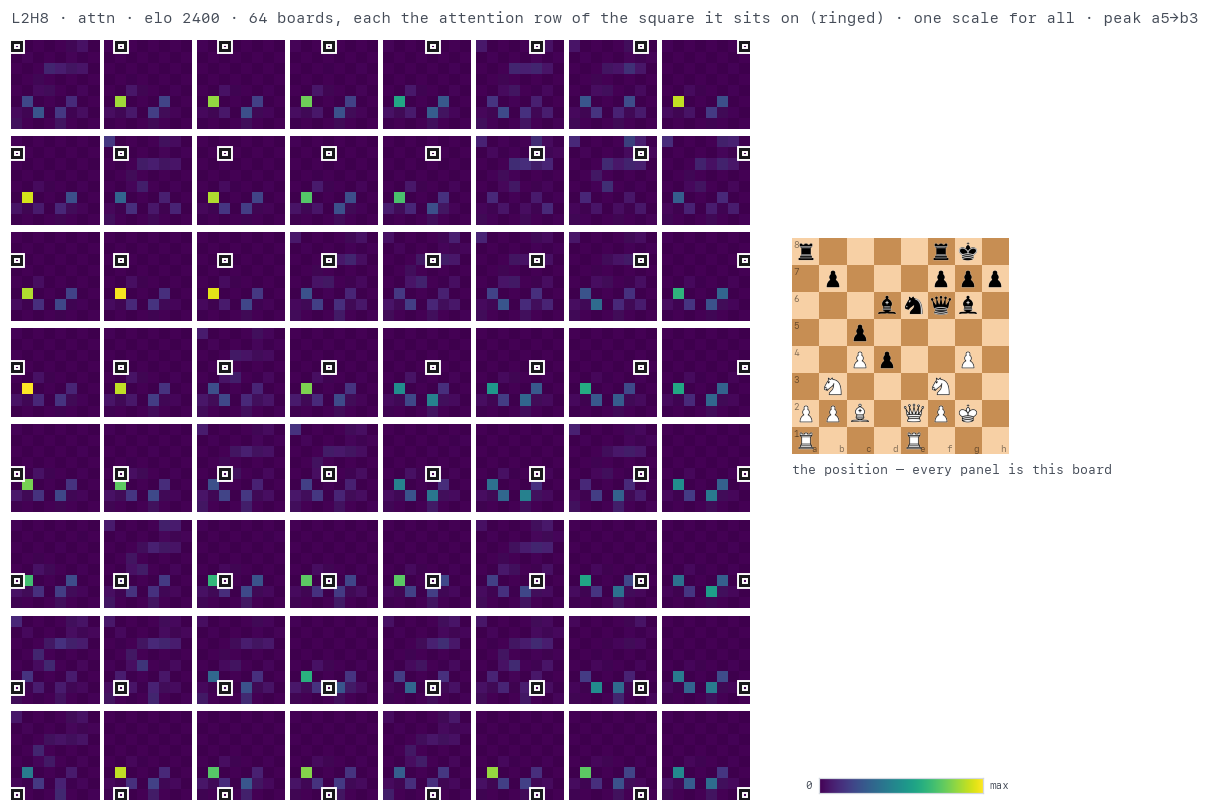

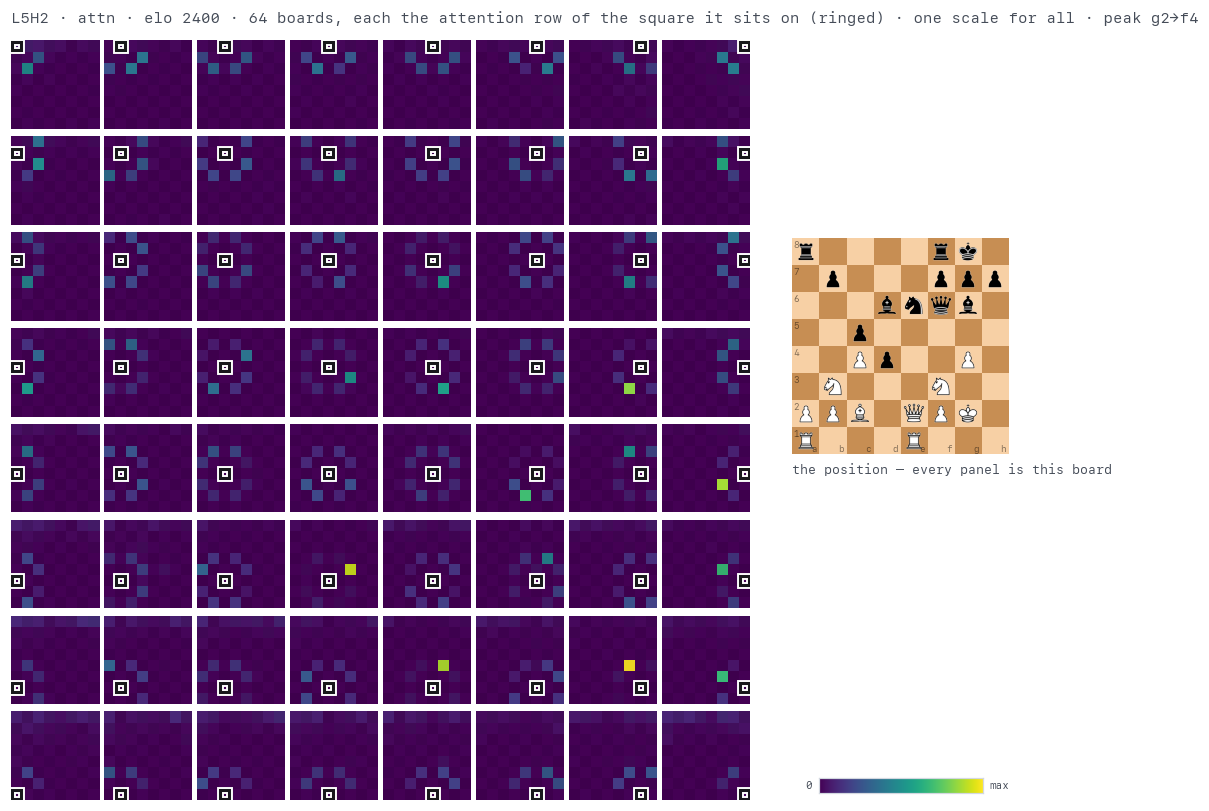

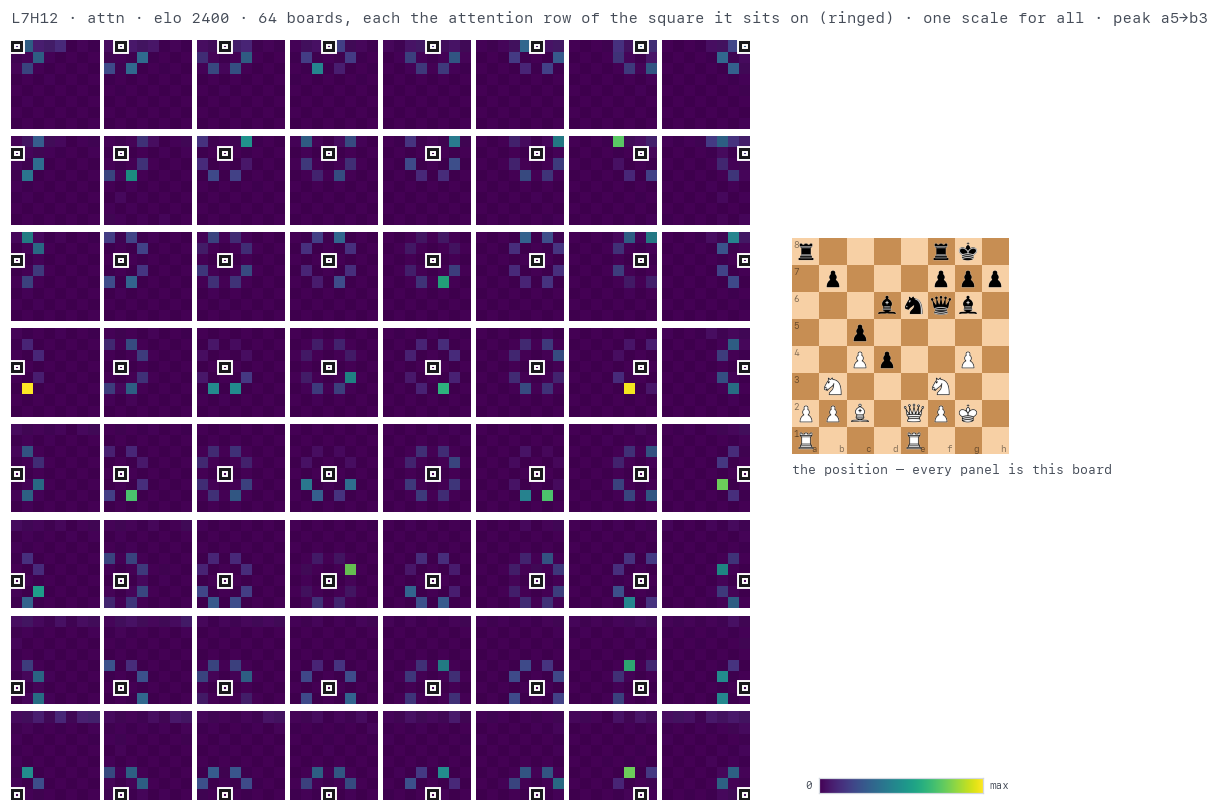

In [41]:
# Attention atlases
for l, h in [ (2, 8), (5, 2), (7, 12)]:
    show(ip.plot_attention_atlas(eng, random_board, elo=2400, layer=l, head=h, figsize=(9.6, 7.7)),
         f"knight_head_atlas, (L{l}H{h})")


In [ ]:
# Attention Widget (not in paper)
# Look at any head this way:


random_board=chess.Board("r4rk1/1p3ppp/3bnqb1/2p5/2Pp2P1/1N3N2/PPB1QPK1/R3R3 b - - 1 1") #or replace with another FEN


from chessformer_lens import interp_widget as iw
iw.attention_widget(eng, random_board, 1500)
